# Student GPA Prediction

## Importing Libraries

In [54]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

## Read the data
[Date set link](https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset?utm_source=chatgpt.com)

In [55]:
df = pd.read_csv ("./data/data.csv") 
df.head ()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## Understanding and exploring data

In [56]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


## From info:

```Python
features = [
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "ParentalSupport"
]
```

target = "GPA"

In [57]:
features = [
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "ParentalSupport"
]

In [58]:
target = "GPA"

In [59]:
df = df [features + [target]]
df.head ()

,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,GPA
0,19.833723,7,1,2,2.929196
1,15.408756,0,0,1,3.042915
2,4.210570,26,0,2,0.112602
3,10.028829,14,0,3,2.054218
4,4.672495,17,1,3,1.288061


In [60]:
df.isnull ().sum ()

StudyTimeWeekly    0
Absences           0
Tutoring           0
ParentalSupport    0
GPA                0
dtype: int64

### Nice 🙂 no missing values.

In [61]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   StudyTimeWeekly  2392 non-null   float64
 1   Absences         2392 non-null   int64  
 2   Tutoring         2392 non-null   int64  
 3   ParentalSupport  2392 non-null   int64  
 4   GPA              2392 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 93.6 KB


### Nice 🙂 no str.
### No issues with our data. 🤷‍♂️

## Visualization and Feature Understanding

Text(0.5, 1.0, 'GPA Distribution')

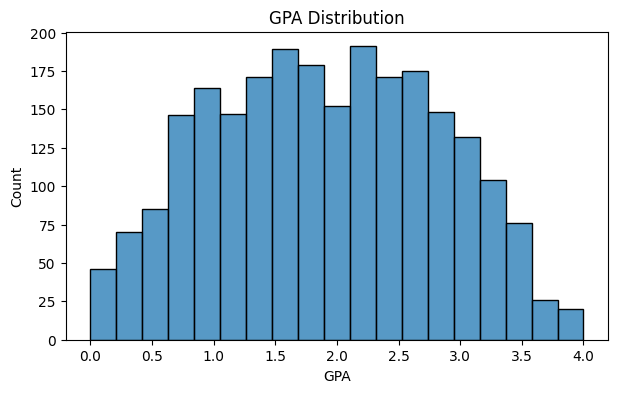

In [62]:
# GPA Distribution
plt.figure (figsize= (7,4))
sns.histplot (df ["GPA"]) # Histogram
plt.xlabel ("GPA")
plt.ylabel ("Count")
plt.title ("GPA Distribution")

Text(0.5, 1.0, 'Study Time vs GPA')

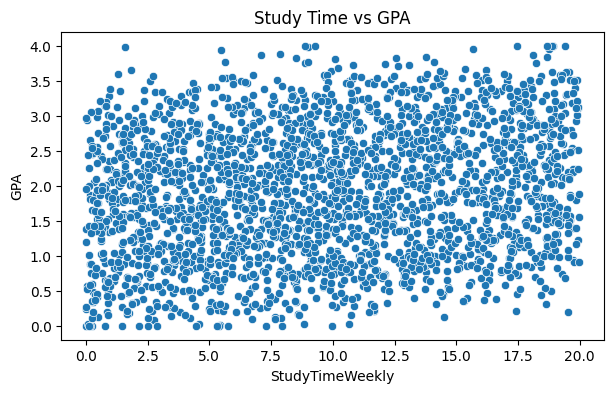

In [63]:
# Study Time vs GPA
plt.figure (figsize= (7,4))
sns.scatterplot (
    x= df ["StudyTimeWeekly"],
    y= df ["GPA"]
)
plt.title ("Study Time vs GPA")

Text(0.5, 1.0, 'Absences vs GPA')

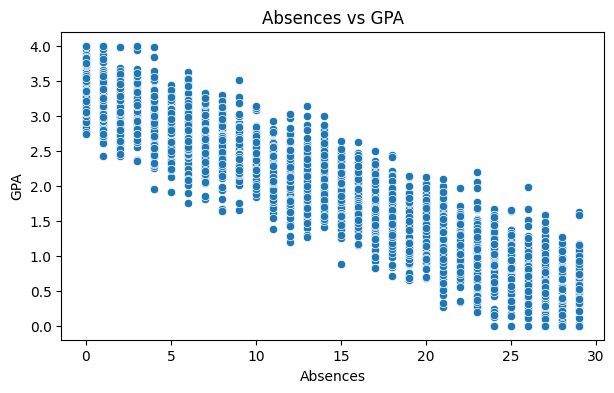

In [64]:
# Absences vs GPA
plt.figure (figsize= (7,4))

sns.scatterplot (
    x= df ["Absences"],
    y= df ["GPA"]
)
plt.title ("Absences vs GPA")

Text(0.5, 1.0, 'Tutoring vs GPA')

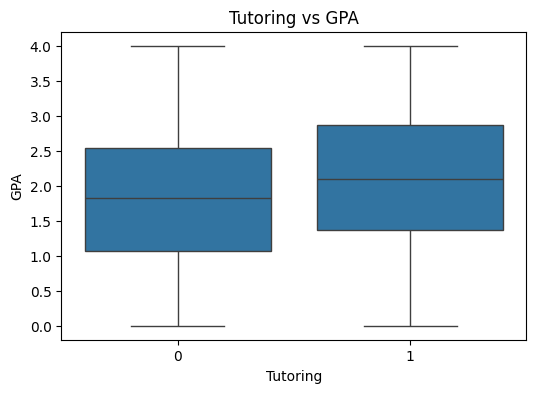

In [65]:
# Tutoring vs GPA
plt.figure (figsize= (6,4))

sns.boxplot (
    x= df ["Tutoring"],
    y= df ["GPA"]
)
plt.title ("Tutoring vs GPA")

Text(0.5, 1.0, 'Parental Support vs GPA')

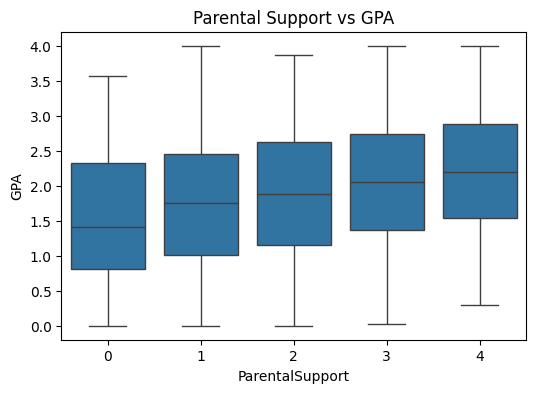

In [66]:
# Parental Support vs GPA
plt.figure (figsize= (6,4))

sns.boxplot (
    x= df ["ParentalSupport"],
    y= df ["GPA"]
)
plt.title ("Parental Support vs GPA")

## Model 🤖

In [67]:
X = df [features] # Features
Y = df ["GPA"]  # Target

### Train / Test split

In [68]:
x_train, x_test, y_train, y_test = train_test_split (
    X, Y,
    test_size= 0.2,
    random_state= 42
)

### Selecting the model and training it

In [69]:
model = LinearRegression ()
model.fit (x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [70]:
y_pred = model.predict (x_test)

In [71]:
mae = mean_absolute_error (y_test, y_pred)
print ("MAE:", mae)

MAE: 0.1858622431290252


| Actual | Predicted | Error |
|--------|-----------|-------|
| 3.2     | 3.1       | 0.1   |
| 2.1     | 2.0       | 0.1   |
| 3.1     | 2.9       | 0.2   |

MAE = (0.1 + 0.1 + 0.2) / 3 = 0.13

In [72]:
study_time = float (input ("Study Time Weekly: "))
absences = float (input ("Absences: "))
tutoring = float (input ("Tutoring (0 = No, 1 = Yes): "))
parental_support = float (input ("Parental Support (0-4): "))

user_data = [[
    study_time,
    absences,
    tutoring,
    parental_support
]]

prediction = model.predict (user_data)

if prediction [0] > 4.0:
    prediction [0] = 4.0

print ("Predicted GPA:", round (prediction [0], 2))

Predicted GPA: 2.47


/home/ahmed/work/projects/Student GPA Prediction/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
